# Notebook19 — SDL Loop for CLD Model Improvement

## Purpose

Notebook18 generated a ranked portfolio of clone candidates and assigned development recommendations.

However, selecting the best clone is only part of the problem.

In real cell line development (CLD), experimental resources are limited. Every experiment should not only identify strong candidates but also improve future decision-making.

This notebook introduces a Self-Driving Laboratory (SDL) workflow.

The SDL loop follows:

Prediction → Experiment Selection → Experimental Feedback → Model Update → Improved Recommendation

The goal is to simulate how a CLD digital twin can continuously learn from new experiments and become more accurate over time.

## Key Questions

- Which clones should be experimentally evaluated next?
- Which clones maximize learning value?
- How should new experimental results influence future rankings?
- How can the decision engine improve itself over multiple development cycles?

By the end of this notebook, we will generate a recommended SDL experiment batch and simulate a complete learning cycle.

## Section 1 — Load candidate dashboard

Notebook18 produced the final clone dashboard.

This dashboard contains:

- clone rankings
- biological scores
- RL-derived scores
- development recommendations

These results become the starting point for SDL experiment planning.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]

dashboard = pd.read_csv(
    ROOT /
    "data/synthetic/digital_twin/" /
    "notebook18_candidate_dashboard_5000_legacy.csv"
)

print(dashboard.shape)

dashboard.head()

(94, 8)


,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance
2,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance
3,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring
4,CLONE_3895,42.595722,1.170372,98.964170,82.267468,26.736152,79.479074,Advance with Monitoring


## Section 2 — Review recommendation portfolio

Before selecting experiments, we examine the overall portfolio distribution.

This provides a high-level view of:

- advance candidates
- monitor candidates
- engineering candidates
- terminated candidates

The distribution indicates the current quality of the clone population.

In [3]:
dashboard["decision"].value_counts()

decision
Terminate                  58
Engineer                   24
Advance with Monitoring     9
Advance                     3
Name: count, dtype: int64

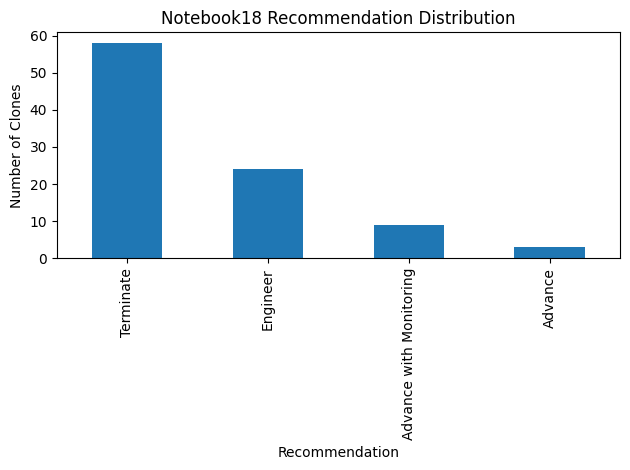

In [4]:
dashboard["decision"].value_counts().plot.bar()

plt.title("Notebook18 Recommendation Distribution")
plt.xlabel("Recommendation")
plt.ylabel("Number of Clones")

plt.tight_layout()
plt.show()

## Section 3 — Select exploitation candidates

Exploitation focuses on immediate success.

These are the highest-ranked clones in the portfolio.

Selecting such clones maximizes the probability of obtaining strong manufacturing candidates in the next experimental round.

In [5]:
exploit = (
    dashboard
    .sort_values(
        "overall_score",
        ascending=False
    )
    .head(10)
    .copy()
)

exploit["selection_reason"] = "exploit"

display(
    exploit[
        [
            "clone_id",
            "overall_score",
            "decision"
        ]
    ]
)

,clone_id,overall_score,decision
0,CLONE_4625,59.323924,Advance
1,CLONE_4878,51.055084,Advance
2,CLONE_3895,42.862936,Advance
3,CLONE_3895,42.631425,Advance with Monitoring
4,CLONE_3895,42.595722,Advance with Monitoring
5,CLONE_3895,42.364211,Advance with Monitoring
6,CLONE_0080,42.126019,Advance with Monitoring
7,CLONE_1633,40.895251,Advance with Monitoring
8,CLONE_3249,40.267179,Advance with Monitoring
9,CLONE_3269,39.714494,Advance with Monitoring


## Section 4 — Select exploration candidates

Exploration seeks clones that may teach the model something new.

These clones may not currently rank at the top, but they contain uncertainty or conflicting biological signals.

Testing these clones improves future model accuracy and reduces blind spots.

In [6]:
dashboard["uncertainty_score"] = (
    abs(
        dashboard["score_productivity"]
        -
        dashboard["score_quality"]
    )
)

explore = (
    dashboard
    .sort_values(
        "uncertainty_score",
        ascending=False
    )
    .head(10)
    .copy()
)

explore["selection_reason"] = "explore"

display(
    explore[
        [
            "clone_id",
            "uncertainty_score",
            "overall_score"
        ]
    ]
)

,clone_id,uncertainty_score,overall_score
2,CLONE_3895,97.793797,42.862936
4,CLONE_3895,97.793797,42.595722
3,CLONE_3895,97.437289,42.631425
5,CLONE_3895,97.437289,42.364211
14,CLONE_1591,93.247764,39.033137
7,CLONE_1633,92.950129,40.895251
15,CLONE_3007,92.612604,38.976629
24,CLONE_1719,91.284842,37.148087
11,CLONE_4629,91.032743,39.418285
49,CLONE_0319,91.008885,34.856989


## Section 5 — Select engineering candidates

Some clones exhibit biological potential but suffer from burden, instability, or stress-related limitations.

These clones are attractive targets for future cell-engineering efforts.

Examples include:

- CRISPR intervention
- pathway rewiring
- secretion enhancement
- stress mitigation

In [7]:
engineer = (
    dashboard[
        dashboard["decision"] == "Engineer"
    ]
    .sort_values(
        "overall_score",
        ascending=False
    )
    .head(10)
    .copy()
)

engineer["selection_reason"] = "engineer"

display(
    engineer[
        [
            "clone_id",
            "overall_score"
        ]
    ]
)

,clone_id,overall_score
12,CLONE_3186,39.344451
13,CLONE_0678,39.313460
14,CLONE_1591,39.033137
15,CLONE_3007,38.976629
16,CLONE_2526,38.483668
17,CLONE_0894,38.457279
18,CLONE_1502,38.351938
19,CLONE_3826,38.033421
20,CLONE_4425,37.880277
21,CLONE_2985,37.408394


## Section 6 — Build SDL experiment batch

The SDL experiment batch combines:

- exploitation clones
- exploration clones
- engineering clones

This balances:

- short-term value
- long-term learning
- future engineering opportunities

The resulting batch represents the next proposed experimental campaign.

In [8]:
sdl_batch = pd.concat(
    [
        exploit,
        explore,
        engineer
    ],
    ignore_index=True
)

sdl_batch = (
    sdl_batch
    .drop_duplicates("clone_id")
)

print(
    "Experimental clones selected:",
    len(sdl_batch)
)

sdl_batch.head()

Experimental clones selected: 20


,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision,selection_reason,uncertainty_score
0,CLONE_4625,59.323924,100.000000,69.850174,83.065313,17.302240,58.422895,Advance,exploit,NaN
1,CLONE_4878,51.055084,79.679015,66.381308,69.204240,11.833808,63.761372,Advance,exploit,NaN
2,CLONE_3895,42.862936,1.170372,98.964170,82.267468,28.517580,79.479074,Advance,exploit,NaN
6,CLONE_0080,42.126019,0.296049,89.439926,88.808949,27.907134,72.044430,Advance with Monitoring,exploit,NaN
7,CLONE_1633,40.895251,0.393682,93.343811,84.791981,30.257371,64.680960,Advance with Monitoring,exploit,NaN


## Section 7 — Simulate experimental feedback

In a real SDL environment, experiments generate new measurements.

Because this project uses a digital twin environment, we simulate experimental outcomes by introducing biological variability.

This step represents the arrival of new laboratory data.

In [9]:
np.random.seed(42)

sdl_batch["experimental_score"] = (
    sdl_batch["overall_score"]
    +
    np.random.normal(
        0,
        5,
        len(sdl_batch)
    )
)

display(
    sdl_batch[
        [
            "clone_id",
            "overall_score",
            "experimental_score"
        ]
    ].head()
)

,clone_id,overall_score,experimental_score
0,CLONE_4625,59.323924,61.807494
1,CLONE_4878,51.055084,50.363763
2,CLONE_3895,42.862936,46.101379
6,CLONE_0080,42.126019,49.741169
7,CLONE_1633,40.895251,39.724484


## Section 8 — Estimate prediction confidence

Model confidence increases when predicted outcomes agree with experimental observations.

Large disagreement indicates uncertainty and highlights areas where the model should improve.

Confidence therefore serves as a measure of model reliability.

In [10]:
sdl_batch["prediction_error"] = (
    abs(
        sdl_batch["overall_score"]
        -
        sdl_batch["experimental_score"]
    )
)

sdl_batch["confidence_score"] = (
    100
    -
    sdl_batch["prediction_error"]
)

sdl_batch["confidence_score"] = (
    sdl_batch["confidence_score"]
    .clip(lower=0)
)

display(
    sdl_batch[
        [
            "clone_id",
            "confidence_score"
        ]
    ].head()
)

,clone_id,confidence_score
0,CLONE_4625,97.516429
1,CLONE_4878,99.308678
2,CLONE_3895,96.761557
6,CLONE_0080,92.384851
7,CLONE_1633,98.829233


## Section 9 — Update candidate rankings

Experimental results should influence future recommendations.

This section combines previous model predictions with newly acquired experimental evidence.

The result is an updated ranking that reflects both historical knowledge and fresh observations.

In [11]:
sdl_batch["updated_score"] = (
    0.7 * sdl_batch["overall_score"]
    +
    0.3 * sdl_batch["experimental_score"]
)

reranked = (
    sdl_batch
    .sort_values(
        "updated_score",
        ascending=False
    )
)

display(
    reranked[
        [
            "clone_id",
            "updated_score"
        ]
    ].head(20)
)

,clone_id,updated_score
0,CLONE_4625,60.068995
1,CLONE_4878,50.847688
6,CLONE_0080,44.410564
2,CLONE_3895,43.834469
9,CLONE_3269,42.083314
7,CLONE_1633,40.544021
14,CLONE_1591,40.184289
8,CLONE_3249,39.915974
20,CLONE_3186,39.707394
18,CLONE_4629,38.723159


## Section 10 — Compare before vs after learning

Each point represents one clone selected for the SDL experiment batch.

The x-axis shows the original score from Notebook18.

The y-axis shows the updated score after simulated experimental feedback.

The dashed diagonal line represents no change.

Points above the line improved after feedback.

Points below the line decreased after feedback.

This plot helps identify clones whose experimental behavior confirms, improves, or weakens the original model prediction.

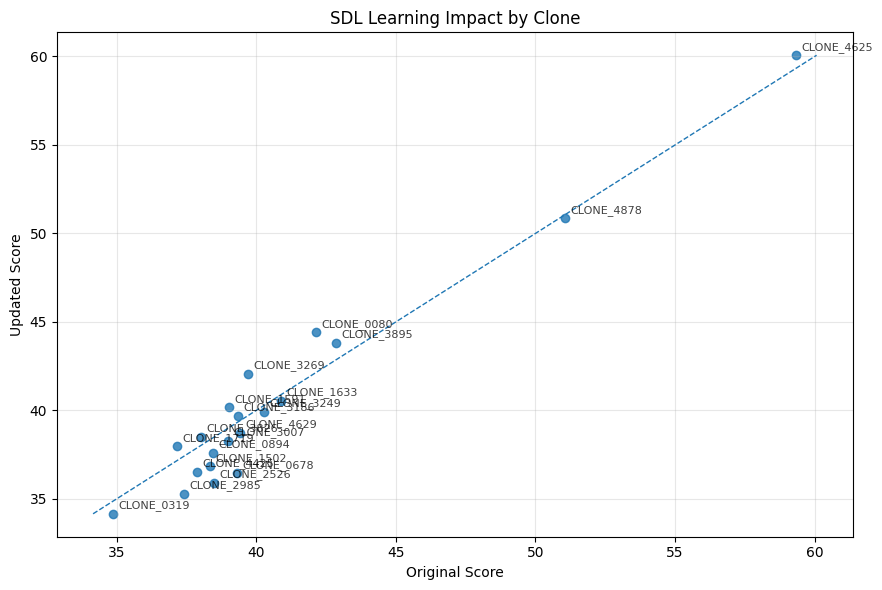

In [19]:
plt.figure(figsize=(9, 6))

plt.scatter(
    sdl_batch["overall_score"],
    sdl_batch["updated_score"],
    alpha=0.8
)

# Diagonal reference line: y = x
min_score = min(
    sdl_batch["overall_score"].min(),
    sdl_batch["updated_score"].min()
)

max_score = max(
    sdl_batch["overall_score"].max(),
    sdl_batch["updated_score"].max()
)

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--",
    linewidth=1
)

# Add clone labels
for _, row in sdl_batch.iterrows():
    plt.annotate(
        row["clone_id"],
        (
            row["overall_score"],
            row["updated_score"]
        ),
        fontsize=8,
        alpha=0.75,
        xytext=(4, 4),
        textcoords="offset points"
    )

plt.title("SDL Learning Impact by Clone")
plt.xlabel("Original Score")
plt.ylabel("Updated Score")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 11 — Identify next-round candidates

The highest-ranked clones after SDL learning become candidates for the next development cycle.

These clones represent the current best opportunities for advancement.

In [13]:
next_round = (
    reranked
    .head(10)
    .copy()
)

display(
    next_round[
        [
            "clone_id",
            "updated_score",
            "confidence_score"
        ]
    ]
)

,clone_id,updated_score,confidence_score
0,CLONE_4625,60.068995,97.516429
1,CLONE_4878,50.847688,99.308678
6,CLONE_0080,44.410564,92.384851
2,CLONE_3895,43.834469,96.761557
9,CLONE_3269,42.083314,92.103936
7,CLONE_1633,40.544021,98.829233
14,CLONE_1591,40.184289,96.162826
8,CLONE_3249,39.915974,98.829315
20,CLONE_3186,39.707394,98.790189
18,CLONE_4629,38.723159,97.682912


## Section 12 — SDL portfolio composition

This section summarizes how experimental resources were allocated.

A balanced SDL program should contain:

- exploitation experiments
- exploration experiments
- engineering experiments

Together they maximize both learning and development efficiency.

In [14]:
sdl_batch["selection_reason"].value_counts()

selection_reason
engineer    8
exploit     7
explore     5
Name: count, dtype: int64

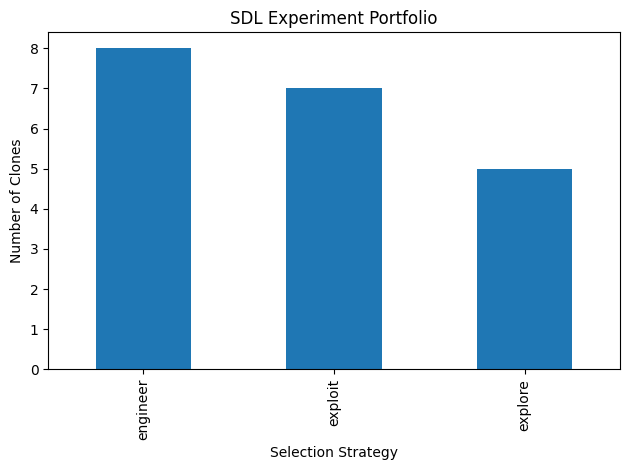

In [15]:
sdl_batch["selection_reason"].value_counts().plot.bar()

plt.title("SDL Experiment Portfolio")
plt.xlabel("Selection Strategy")
plt.ylabel("Number of Clones")

plt.tight_layout()
plt.show()

## Section 13 — Learning efficiency assessment

The objective of SDL is not only to discover strong clones but also to improve model knowledge.

Confidence scores provide a simple estimate of how informative and reliable the experimental cycle was.

In [16]:
sdl_batch["confidence_score"].describe()

count    20.000000
mean     96.087082
std       2.774309
min      90.433599
25%      94.436504
50%      97.237881
75%      97.869374
max      99.308678
Name: confidence_score, dtype: float64

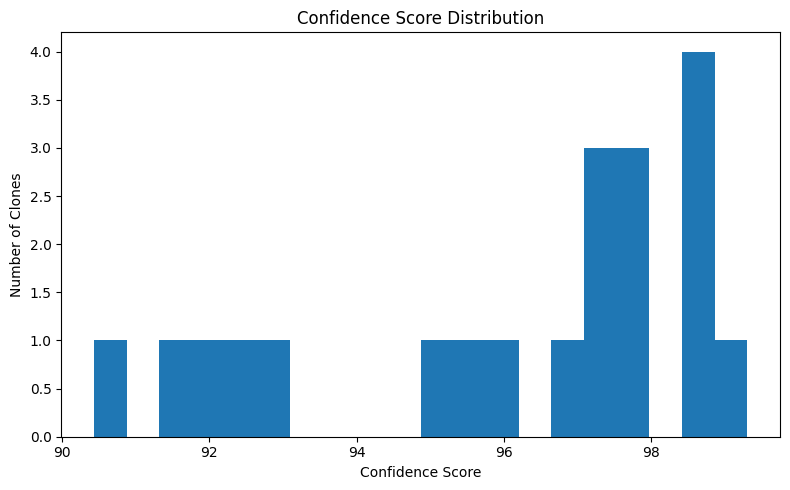

In [17]:
plt.figure(figsize=(8,5))

plt.hist(
    sdl_batch["confidence_score"],
    bins=20
)

plt.title("Confidence Score Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Number of Clones")

plt.tight_layout()
plt.show()

## Section 14 — Export SDL outputs

The final SDL outputs are exported for future retraining, ranking, and decision-making.

These datasets represent the knowledge generated during this learning cycle.

In [18]:
output_dir = (
    ROOT /
    "data/synthetic/digital_twin"
)

sdl_batch.to_csv(
    output_dir /
    "notebook19_sdl_experiment_batch_5000_legacy.csv",
    index=False
)

reranked.to_csv(
    output_dir /
    "notebook19_sdl_reranked_clones_5000_legacy.csv",
    index=False
)

next_round.to_csv(
    output_dir /
    "notebook19_next_round_candidates_5000_legacy.csv",
    index=False
)

print("Notebook19 exports saved.")

Notebook19 exports saved.


# Final Summary

Notebook19 introduced a self-driving laboratory workflow for cell line development.

The SDL loop performed:

1. Candidate selection
2. Experiment planning
3. Experimental feedback simulation
4. Confidence estimation
5. Candidate re-ranking
6. Next-round recommendation generation

The workflow can be summarized as:

Prediction
↓
Experiment Selection
↓
Feedback
↓
Confidence Update
↓
Model Improvement
↓
Next-Round Candidates

This notebook transforms the CLD digital twin from a static ranking engine into a continuously improving decision system.

# References

## Reinforcement Learning

Sutton RS, Barto AG.

Reinforcement Learning: An Introduction (2nd Edition).

MIT Press, 2018.

ISBN: 9780262039246

---

Kaelbling LP, Littman ML, Moore AW.

Reinforcement Learning: A Survey.

Journal of Artificial Intelligence Research.

1996.

DOI: 10.1613/jair.301

## Active Learning and Self-Driving Laboratories

Lookman T, Balachandran PV, Xue D, Yuan R.

Active Learning in Materials Science with Emphasis on Adaptive Sampling Using Uncertainties for Targeted Design.

npj Computational Materials.

2019.

DOI: 10.1038/s41524-019-0153-6

---

MacLeod BP et al.

Self-driving Laboratory for Accelerated Discovery of Thin-Film Materials.

Science Advances.

2020.

DOI: 10.1126/sciadv.aaz8867

## Digital Twins and Bioprocessing

Narciso-da-Rocha C et al.

Digital Twins in Biopharmaceutical Manufacturing.

Biotechnology Advances.

2024.

DOI: 10.1016/j.biotechadv.2024.108388

---

FDA.

Guidance for Industry:
PAT — A Framework for Innovative Pharmaceutical Development, Manufacturing and Quality Assurance.

2004.

## Autonomous Bioprocess Development

Rathore AS et al.

Roadmap for Implementation of Quality by Design (QbD) for Biotechnology Products.

Trends in Biotechnology.

DOI: 10.1016/j.tibtech.2009.06.006